# 04 - Construcao do grafo

Valida visualmente `atoms_to_graph`: 3 estruturas com as arestas sobrepostas em 3D, coloridas por tag (2=H adsorvido, 1=superficie, 0=sub-superficie). Confirma que o H conecta aos atomos certos e que nenhuma aresta cruza o vacuo em z (pbc = [True, True, False]).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from ase.data import chemical_symbols

from her_gnn.data.dataset import HERDataset

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
import os
os.chdir(ROOT)

dataset = HERDataset(root="data", cutoff=6.0)
print(f"grafos: {len(dataset)}")

grafos: 5860


In [2]:
TAG_COLOR = {0: "#bbbbbb", 1: "#4c72b0", 2: "#d62728"}
TAG_NAME = {0: "sub-superficie", 1: "superficie", 2: "H adsorvido"}

def plot_graph(data, ax):
    pos = data.pos.numpy()
    tags = data.tags.numpy()
    ei = data.edge_index.numpy()
    for a, b in ei.T:
        ax.plot(*zip(pos[a], pos[b]), color="0.7", lw=0.3, alpha=0.5)
    for t in (0, 1, 2):
        m = tags == t
        if m.any():
            ax.scatter(*pos[m].T, c=TAG_COLOR[t], s=60 if t == 2 else 40,
                       label=TAG_NAME[t], depthshade=False, edgecolors="k", linewidths=0.3)
    ax.set_title(f"{data.sid}\n{data.num_nodes} atomos, {ei.shape[1]} arestas", fontsize=8)
    ax.set_zlabel("z")

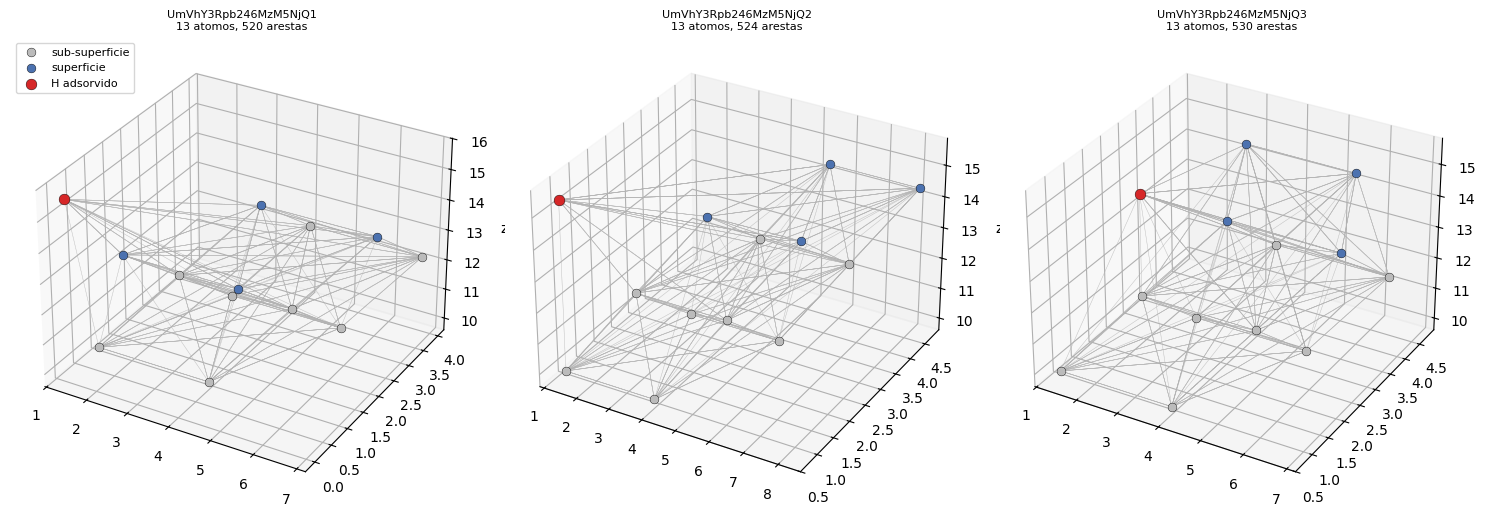

In [3]:
fig = plt.figure(figsize=(15, 5))
for k in range(3):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    plot_graph(dataset[k], ax)
    if k == 0:
        ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## Sanidade: arestas e vizinhanca do H

Nenhuma aresta deve abranger o vacuo em z (span << espessura do slab + vacuo). E o H deve ter vizinhos da superficie.

In [4]:
for k in range(3):
    d = dataset[k]
    pos, ei, tags = d.pos.numpy(), d.edge_index.numpy(), d.tags.numpy()
    z_span = np.abs(pos[ei[0], 2] - pos[ei[1], 2])
    cell_z = float(d.cell[0, 2, 2])
    h_idx = np.where(tags == 2)[0]
    h_edges = np.isin(ei[0], h_idx)
    h_neighbors = tags[ei[1][h_edges]]
    print(f"{d.sid}: max edge z-span={z_span.max():.2f} A (cell z={cell_z:.1f}), "
          f"max edge weight={d.edge_weight.max():.2f}, "
          f"H tem {h_edges.sum()} arestas para tags {sorted(set(h_neighbors.tolist()))}")
    assert z_span.max() < cell_z, "aresta cruzando vacuo em z!"

UmVhY3Rpb246MzM5NjQ1: max edge z-span=5.60 A (cell z=24.4), max edge weight=5.98, H tem 35 arestas para tags [0, 1, 2]
UmVhY3Rpb246MzM5NjQ2: max edge z-span=5.46 A (cell z=24.4), max edge weight=5.77, H tem 37 arestas para tags [0, 1, 2]
UmVhY3Rpb246MzM5NjQ3: max edge z-span=5.42 A (cell z=24.4), max edge weight=5.77, H tem 40 arestas para tags [0, 1, 2]
